In [2]:
# generating customized synthetic csv dataset 'hospital.csv' using Numpy and pandas(python) for analysis:

import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

df = pd.DataFrame({
    "patient_id": range(1, n+1),
    "age": np.random.randint(1, 90, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "department": np.random.choice(
        ["Cardiology", "Orthopedics", "Neurology", "General", "ICU"], n),
    "diagnosis": np.random.choice(
        ["Heart Disease", "Fracture", "Stroke", "Infection", "Diabetes"], n),
    "admission_date": pd.to_datetime("2023-01-01") + 
                      pd.to_timedelta(np.random.randint(0, 365, n), unit='D')
})

# Discharge after 1–15 days
df["length_of_stay"] = np.random.randint(1, 15, n)
df["discharge_date"] = df["admission_date"] + pd.to_timedelta(df["length_of_stay"], unit='D')

# Treatment cost (depends on stay + department)
base_cost = df["length_of_stay"] * np.random.randint(2000, 5000, n)
dept_multiplier = df["department"].map({
    "ICU": 2.5,
    "Cardiology": 2,
    "Neurology": 2,
    "Orthopedics": 1.5,
    "General": 1
})

df["treatment_cost"] = (base_cost * dept_multiplier).astype(int)

# Readmission probability
df["readmitted"] = np.where(
    (df["length_of_stay"] > 7) & (df["age"] > 60),
    np.random.choice([0,1], n, p=[0.6,0.4]),
    np.random.choice([0,1], n, p=[0.85,0.15])
)

# Save dataset
df.to_csv("hospital.csv", index=False)

print("Dataset created: hospital.csv")

Dataset created: hospital.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
# reading synthetic csv dataset:

df = pd.read_csv(r"C:\Users\USER\Documents\hospital.csv")

In [5]:
df.head()

,patient_id,age,gender,department,diagnosis,admission_date,length_of_stay,discharge_date,treatment_cost,readmitted
0,1,52,Male,Cardiology,Infection,2023-12-12,2,2023-12-14,15024,0
1,2,15,Male,Cardiology,Infection,2023-12-31,3,2024-01-03,20160,0
2,3,72,Male,ICU,Heart Disease,2023-12-16,12,2023-12-28,137040,0
3,4,61,Female,ICU,Stroke,2023-12-02,2,2023-12-04,21865,0
4,5,21,Female,Orthopedics,Infection,2023-04-04,10,2023-04-14,47925,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      5000 non-null   int64 
 1   age             5000 non-null   int64 
 2   gender          5000 non-null   object
 3   department      5000 non-null   object
 4   diagnosis       5000 non-null   object
 5   admission_date  5000 non-null   object
 6   length_of_stay  5000 non-null   int64 
 7   discharge_date  5000 non-null   object
 8   treatment_cost  5000 non-null   int64 
 9   readmitted      5000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [7]:
df.describe()

,patient_id,age,length_of_stay,treatment_cost,readmitted
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,44.380600,7.513800,47472.739200,0.184200
std,1443.520003,25.551632,4.044389,32723.925802,0.387686
min,1.000000,1.000000,1.000000,2054.000000,0.000000
25%,1250.750000,22.000000,4.000000,21184.500000,0.000000
50%,2500.500000,44.000000,7.000000,41113.500000,0.000000
75%,3750.250000,66.000000,11.000000,66990.000000,0.000000
max,5000.000000,89.000000,14.000000,174405.000000,1.000000


In [8]:
#Data Cleaning:

#Convert Dates:

df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      5000 non-null   int64         
 1   age             5000 non-null   int64         
 2   gender          5000 non-null   object        
 3   department      5000 non-null   object        
 4   diagnosis       5000 non-null   object        
 5   admission_date  5000 non-null   datetime64[ns]
 6   length_of_stay  5000 non-null   int64         
 7   discharge_date  5000 non-null   datetime64[ns]
 8   treatment_cost  5000 non-null   int64         
 9   readmitted      5000 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(3)
memory usage: 390.8+ KB


In [9]:
#Checking null values:

df.isnull().sum()

patient_id        0
age               0
gender            0
department        0
diagnosis         0
admission_date    0
length_of_stay    0
discharge_date    0
treatment_cost    0
readmitted        0
dtype: int64

In [10]:
#Dropping null value rows if any:

df.dropna()

,patient_id,age,gender,department,diagnosis,admission_date,length_of_stay,discharge_date,treatment_cost,readmitted
0,1,52,Male,Cardiology,Infection,2023-12-12,2,2023-12-14,15024,0
1,2,15,Male,Cardiology,Infection,2023-12-31,3,2024-01-03,20160,0
2,3,72,Male,ICU,Heart Disease,2023-12-16,12,2023-12-28,137040,0
3,4,61,Female,ICU,Stroke,2023-12-02,2,2023-12-04,21865,0
4,5,21,Female,Orthopedics,Infection,2023-04-04,10,2023-04-14,47925,0
...,...,...,...,...,...,...,...,...,...,...
4995,4996,89,Female,Orthopedics,Infection,2023-11-22,14,2023-12-06,87381,0
4996,4997,62,Male,General,Heart Disease,2023-04-03,11,2023-04-14,45661,0
4997,4998,13,Female,Neurology,Heart Disease,2023-06-14,9,2023-06-23,47142,0
4998,4999,81,Female,Cardiology,Heart Disease,2023-08-03,6,2023-08-09,42372,0


In [11]:
#Validating Data Logic:

# Stay must be positive:
df = df[df['discharge_date'] >= df['admission_date']]

# Cost must be positive:
df = df[df['treatment_cost'] > 0]

In [12]:
#Recreating Length of Stay:

df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

In [13]:
df['length_of_stay']

0        2
1        3
2       12
3        2
4       10
        ..
4995    14
4996    11
4997     9
4998     6
4999     7
Name: length_of_stay, Length: 5000, dtype: int64

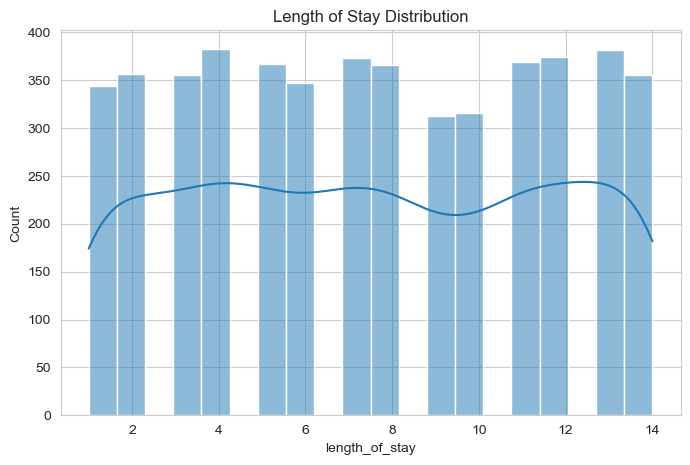

In [14]:
#Univariate EDA (Single Variable):

#Length of Stay:

plt.figure(figsize=(8,5))
sns.histplot(df['length_of_stay'], bins=20, kde=True)
plt.title("Length of Stay Distribution")
plt.show()


In [ ]:
#Insight: Length of stay is quite evenly spread

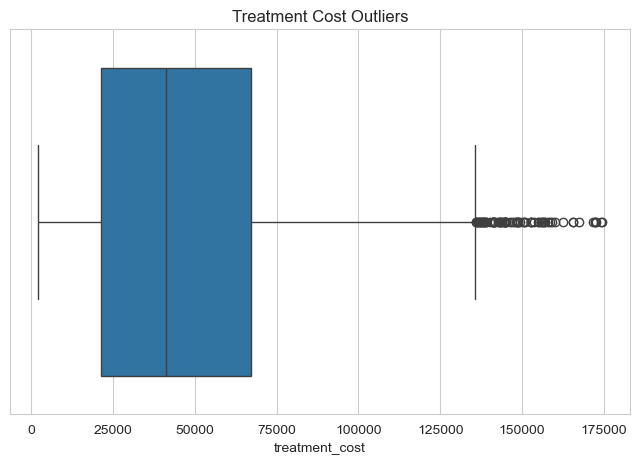

In [15]:
#Treatment Cost:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['treatment_cost'])
plt.title("Treatment Cost Outliers")
plt.show()

In [ ]:
#Insight: Some patients have very high treatment costs(outliers)

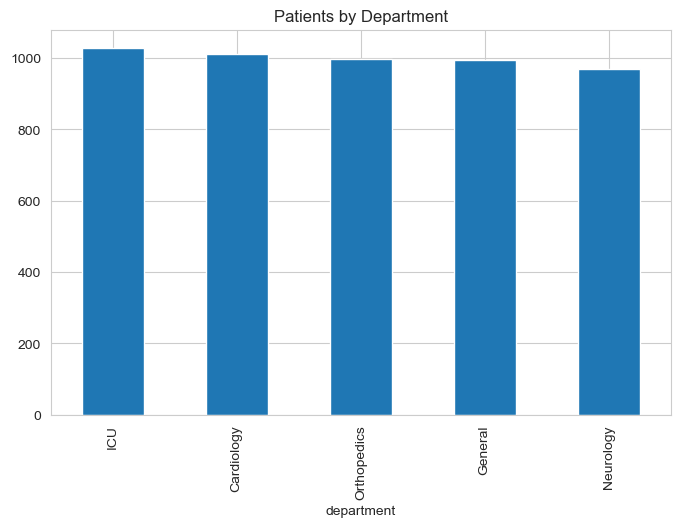

In [16]:
#Department Distribution:

df['department'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Patients by Department")
plt.show()

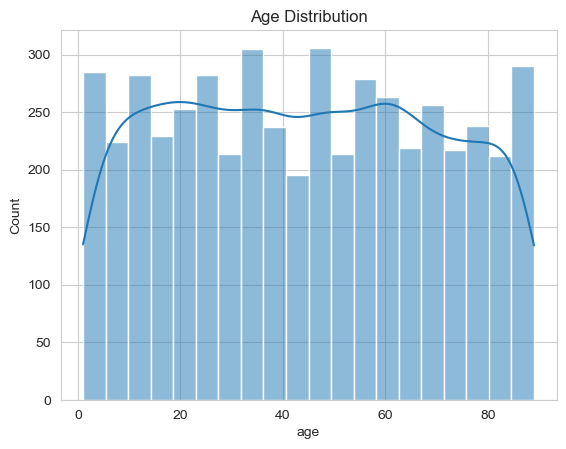

In [17]:
#Age Distribution:

sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

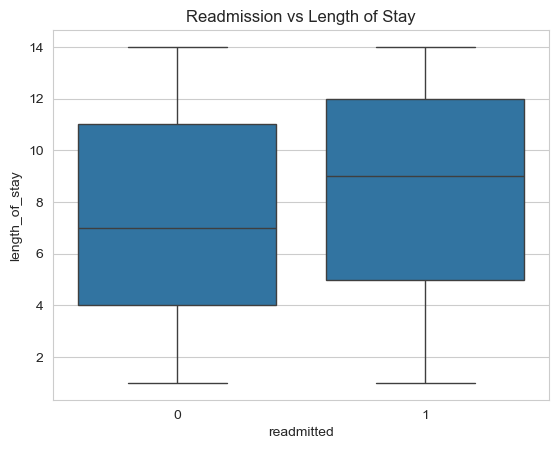

In [18]:
#Bivariate EDA (Relationships):

#Readmission vs Stay:

sns.boxplot(x='readmitted', y='length_of_stay', data=df)
plt.title("Readmission vs Length of Stay")
plt.show()

In [ ]:
#Insight: Higher stay → more readmissions

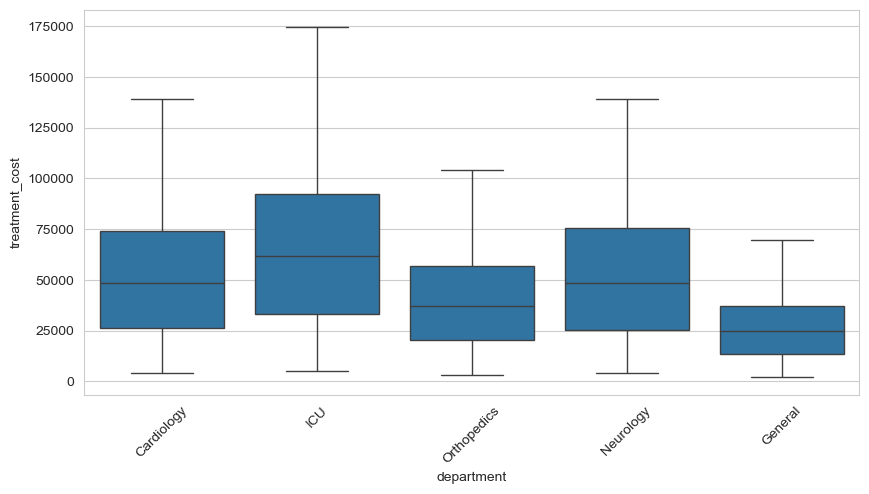

In [19]:
#Cost vs Department:

plt.figure(figsize=(10,5))
sns.boxplot(x='department', y='treatment_cost', data=df)
plt.xticks(rotation=45)
plt.show()

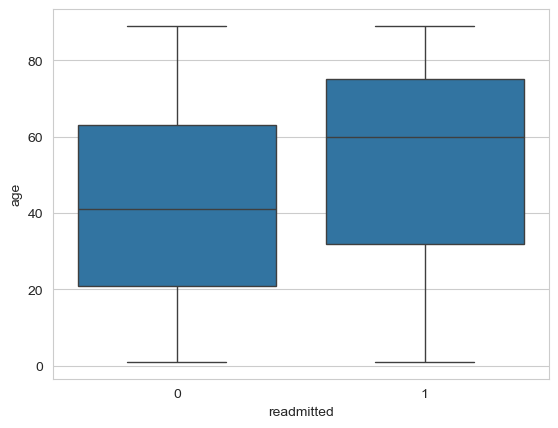

In [20]:
#Age vs Readmission:

sns.boxplot(x='readmitted', y='age', data=df)
plt.show()

In [ ]:
#Insight: Older patients have higher chances of being re-admitted. 

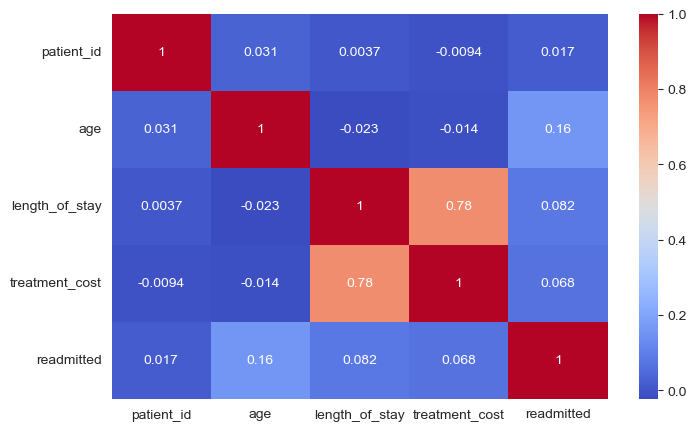

In [21]:
#Correlation Matrix:

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Insight: Treatment costs are highly correlated with length of stay.

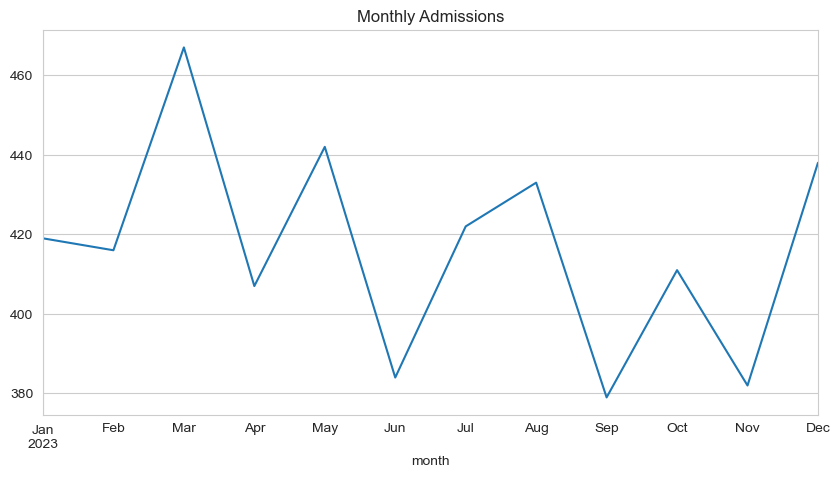

In [22]:
#Time-Based Analysis:

#Monthly Admissions Trend:

df['month'] = df['admission_date'].dt.to_period('M')

monthly = df.groupby('month').size()

monthly.plot(figsize=(10,5), title="Monthly Admissions")
plt.show()

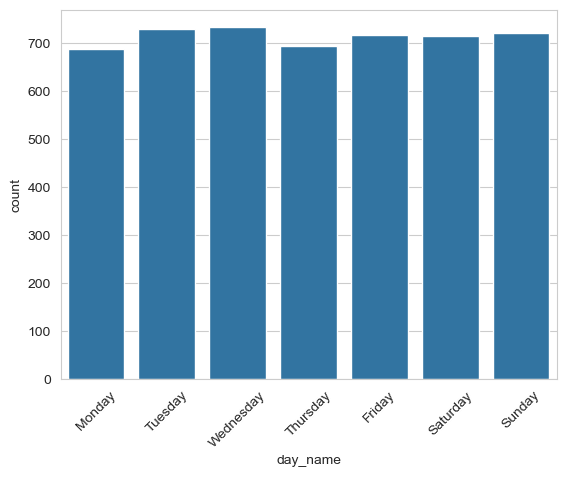

In [23]:
#Day-wise Pattern:

df['day_name'] = df['admission_date'].dt.day_name()

sns.countplot(x='day_name', data=df, order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
plt.xticks(rotation=45)
plt.show()

In [24]:
#Feature Engineering:

#Age Groups:

df['age_group'] = pd.cut(
    df['age'],
    bins=[0,18,35,60,100],
    labels=['Child','Young','Adult','Senior']
)

In [25]:
#Stay Category:

df['stay_category'] = pd.cut(
    df['length_of_stay'],
    bins=[0,3,7,14,30],
    labels=['Short','Medium','Long','Critical']
)

In [26]:
#Cost Category:

df['cost_category'] = pd.qcut(
    df['treatment_cost'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

In [27]:
#Time Features:

df['year'] = df['admission_date'].dt.year
df['month_num'] = df['admission_date'].dt.month
df['weekend'] = df['admission_date'].dt.weekday >= 5

In [28]:
#High Risk Patients:

df['high_risk'] = np.where(
    (df['age'] > 60) & (df['length_of_stay'] > 7),
    1, 0
)

In [29]:
#Department Load Index:

dept_load = df['department'].value_counts(normalize=True)

df['dept_load_index'] = df['department'].map(dept_load)

In [30]:
#Cost per Day:

df['cost_per_day'] = df['treatment_cost'] / df['length_of_stay']

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       5000 non-null   int64         
 1   age              5000 non-null   int64         
 2   gender           5000 non-null   object        
 3   department       5000 non-null   object        
 4   diagnosis        5000 non-null   object        
 5   admission_date   5000 non-null   datetime64[ns]
 6   length_of_stay   5000 non-null   int64         
 7   discharge_date   5000 non-null   datetime64[ns]
 8   treatment_cost   5000 non-null   int64         
 9   readmitted       5000 non-null   int64         
 10  month            5000 non-null   period[M]     
 11  day_name         5000 non-null   object        
 12  age_group        5000 non-null   category      
 13  stay_category    5000 non-null   category      
 14  cost_category    5000 non-null   categor

In [39]:
# Generating cleaned data in csv format for SQL analysis:

df.to_csv("cleaned_hospital_data.csv", index=False)

In [ ]:
# Key Insights:

# Longer stay increases treatment cost.
# Older patients have higher chances of getting re-admitted.
# Monthly variations in admission trends are observed.
# Some departments have higher treatment costs than others.